# Importing Dependencies

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [3]:
from sklearn.metrics import accuracy_score , classification_report
import warnings
import math

from rich import print
warnings.filterwarnings("ignore")

print("[green]Importing Libraries Successfully...[green]")

Importing Libraries Successfully...

# Data Importation

In [5]:
df = pd.read_csv('train.csv')
df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [6]:
df.tail()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
74106,14549287,4.605170,Apartment,Private room,{},1,1.0,Real Bed,flexible,False,...,40.709025,-73.939405,one room bushwick,Williamsburg,0,NaN,https://a0.muscache.com/im/pictures/55162426/6...,11206.0,1.0,1.0
74107,13281809,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,...,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16,93.0,https://a0.muscache.com/im/pictures/2b86560b-a...,90254,2.0,4.0
74108,18688039,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,...,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206.0,2.0,2.0
74109,17045948,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,...,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,NaN,https://a0.muscache.com/im/pictures/b3971b63-0...,10011,0.0,2.0
74110,3534845,4.852030,Boat,Entire home/apt,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",4,1.0,Real Bed,moderate,False,...,33.761096,-118.192409,Cozy Boat at Shoreline Village,Long Beach,205,96.0,https://a0.muscache.com/im/pictures/22968537/d...,90802,1.0,2.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [8]:
df.describe()

,id,log_price,accommodates,bathrooms,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds
count,7.411100e+04,74111.000000,74111.000000,73911.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868
std,6.081735e+06,0.717394,2.153589,0.582044,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142
min,3.440000e+02,0.000000,1.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000
max,2.123090e+07,7.600402,16.000000,8.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000


In [9]:
df.describe(include='all')

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
count,7.411100e+04,74111.000000,74111,74111,74111,74111.000000,73911.000000,74111,74111,74111,...,74111.000000,74111.000000,74111,67239,74111.000000,57389.000000,65895,73145,74020.000000,73980.000000
unique,NaN,NaN,35,3,67122,NaN,NaN,5,5,2,...,NaN,NaN,73359,619,NaN,NaN,65883,769,NaN,NaN
top,NaN,NaN,Apartment,Entire home/apt,{},NaN,NaN,Real Bed,strict,True,...,NaN,NaN,Bunk bed in the Treat Street Clubhouse,Williamsburg,NaN,NaN,https://a0.muscache.com/im/pictures/70087089/b...,11211.0,NaN,NaN
freq,NaN,NaN,49003,41310,586,NaN,NaN,72028,32374,54403,...,NaN,NaN,8,2862,NaN,NaN,3,1368,NaN,NaN
mean,1.126662e+07,4.782069,NaN,NaN,NaN,3.155146,1.235263,NaN,NaN,NaN,...,38.445958,-92.397525,NaN,NaN,20.900568,94.067365,NaN,NaN,1.265793,1.710868
std,6.081735e+06,0.717394,NaN,NaN,NaN,2.153589,0.582044,NaN,NaN,NaN,...,3.080167,21.705322,NaN,NaN,37.828641,7.836556,NaN,NaN,0.852143,1.254142
min,3.440000e+02,0.000000,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,...,33.338905,-122.511500,NaN,NaN,0.000000,20.000000,NaN,NaN,0.000000,0.000000
25%,6.261964e+06,4.317488,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,...,34.127908,-118.342374,NaN,NaN,1.000000,92.000000,NaN,NaN,1.000000,1.000000
50%,1.225415e+07,4.709530,NaN,NaN,NaN,2.000000,1.000000,NaN,NaN,NaN,...,40.662138,-76.996965,NaN,NaN,6.000000,96.000000,NaN,NaN,1.000000,1.000000
75%,1.640226e+07,5.220356,NaN,NaN,NaN,4.000000,1.000000,NaN,NaN,NaN,...,40.746096,-73.954660,NaN,NaN,23.000000,100.000000,NaN,NaN,1.000000,2.000000


In [10]:
print(f"The no rows are : {df.shape[0]}")
print(f"The no of columns are : {df.shape[1]}")

The no rows are : 74111

The no of columns are : 29

In [11]:
print(df.nunique())

id                        74111
log_price                   767
property_type                35
room_type                     3
amenities                 67122
accommodates                 16
bathrooms                    17
bed_type                      5
cancellation_policy           5
cleaning_fee                  2
city                          6
description               73479
first_review               2554
host_has_profile_pic          2
host_identity_verified        2
host_response_rate           80
host_since                 3087
instant_bookable              2
last_review                1371
latitude                  74111
longitude                 74111
name                      73359
neighbourhood               619
number_of_reviews           371
review_scores_rating         54
thumbnail_url             65883
zipcode                     769
bedrooms                     11
beds                         18
dtype: int64

In [12]:
print("duplicates:" , df.duplicated().sum())

duplicates: 0

# Checking Missing Values

In [14]:
df.isnull().sum()

id                            0
log_price                     0
property_type                 0
room_type                     0
amenities                     0
accommodates                  0
bathrooms                   200
bed_type                      0
cancellation_policy           0
cleaning_fee                  0
city                          0
description                   0
first_review              15864
host_has_profile_pic        188
host_identity_verified      188
host_response_rate        18299
host_since                  188
instant_bookable              0
last_review               15827
latitude                      0
longitude                     0
name                          0
neighbourhood              6872
number_of_reviews             0
review_scores_rating      16722
thumbnail_url              8216
zipcode                     966
bedrooms                     91
beds                        131
dtype: int64

# Data Cleaning

In [16]:
df.dropna(inplace=True)

In [17]:
df.drop(columns=['name' , 'neighbourhood'  , 'id'  , 'zipcode'], inplace=True)
df.drop(columns=['bed_type' , 'cleaning_fee' , 'instant_bookable' , 'thumbnail_url'], inplace=True)
df.drop(columns=['host_has_profile_pic' , 'description' , 'host_response_rate' , 'host_since'], inplace=True)
df.drop(columns=['first_review' , 'last_review' , 'cancellation_policy' ], inplace=True)
df.drop(columns=['host_identity_verified' ], inplace=True)

In [18]:
print(f'Shape : {df.shape}')

Shape : (38502, 13)

In [19]:
df.isnull().sum()

log_price               0
property_type           0
room_type               0
amenities               0
accommodates            0
bathrooms               0
city                    0
latitude                0
longitude               0
number_of_reviews       0
review_scores_rating    0
bedrooms                0
beds                    0
dtype: int64

In [20]:
df.shape

(38502, 13)

# Encoding Categorical Data

In [22]:
print("duplicates:" , df.duplicated().sum())

duplicates: 0

In [23]:
print(df['city'].unique())
print(df['room_type'].unique())

['NYC' 'SF' 'LA' 'Boston' 'Chicago' 'DC']

['Entire home/apt' 'Private room' 'Shared room']

In [24]:
df['city'] = df['city'].map({'NYC':0 , 'SF':1 , 'LA':2 , 'Boston':3 , 'Chicago':4 , 'DC':5})
df['room_type'] = df['room_type'].map({'Entire home/apt':0 , 'Private room':1 , 'Shared room':2 })

In [25]:
print(df['property_type'].unique())

['Apartment' 'Condominium' 'House' 'Townhouse' 'Loft' 'Hostel'
 'Guest suite' 'Bungalow' 'Guesthouse' 'Dorm' 'Other' 'Bed & Breakfast'
 'Boutique hotel' 'Villa' 'Timeshare' 'In-law' 'Boat' 'Camper/RV' 'Castle'
 'Cabin' 'Treehouse' 'Serviced apartment' 'Tipi' 'Hut' 'Vacation home'
 'Tent' 'Chalet' 'Yurt' 'Earth House' 'Train' 'Cave']

In [26]:
ord_data = [['Apartment', 'Condominium', 'House', 'Loft', 'Townhouse', 'Hostel',
       'Guest suite', 'Bed & Breakfast', 'Bungalow', 'Guesthouse', 'Dorm',
       'Other', 'Camper/RV', 'Boutique hotel', 'Villa', 'Timeshare',
       'In-law', 'Boat', 'Serviced apartment', 'Castle', 'Cabin',
       'Treehouse', 'Tipi', 'Tent', 'Hut', 'Vacation home', 'Chalet',
       'Yurt', 'Earth House', 'Train', 'Cave', 'Island']]

In [27]:
from sklearn.preprocessing import OrdinalEncoder
OE = OrdinalEncoder(categories=ord_data)
OE.fit(df[['property_type']])

OrdinalEncoder(categories=[['Apartment', 'Condominium', 'House', 'Loft',
                            'Townhouse', 'Hostel', 'Guest suite',
                            'Bed & Breakfast', 'Bungalow', 'Guesthouse', 'Dorm',
                            'Other', 'Camper/RV', 'Boutique hotel', 'Villa',
                            'Timeshare', 'In-law', 'Boat', 'Serviced apartment',
                            'Castle', 'Cabin', 'Treehouse', 'Tipi', 'Tent',
                            'Hut', 'Vacation home', 'Chalet', 'Yurt',
                            'Earth House', 'Train', ...]])

In [28]:
df['property_type'] = OE.transform(df[['property_type']])

In [29]:
df['amenities_count'] = df['amenities'].apply(lambda x: len(x.split(',')))

In [30]:
df.drop(columns='amenities' , inplace=True)

In [31]:
df.head(3)

,log_price,property_type,room_type,accommodates,bathrooms,city,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,amenities_count
1,5.129899,0.0,0,7,1.0,0,40.766115,-73.989040,6,93.0,3.0,3.0,15
2,4.976734,0.0,0,5,1.0,0,40.808110,-73.943756,10,92.0,1.0,3.0,19
5,4.442651,0.0,1,2,1.0,1,37.753164,-122.429526,3,100.0,1.0,1.0,10


# Outlier Handling

In [33]:
df.shape

(38502, 13)

In [34]:
Q1 = df['log_price'].quantile(0.25)
Q3 = df['log_price'].quantile(0.75)
Q1 , Q3

(4.30406509320417, 5.1647859739235145)

In [35]:
IQR = Q3-Q1
IQR

0.8607208807193443

In [36]:
Min_Range = Q1 - (1.5*IQR)
Max_Range = Q3+(1.5*IQR)

In [37]:
Min_Range , Max_Range

(3.012983772125154, 6.45586729500253)

In [38]:
df = df[df['log_price']<=Max_Range]

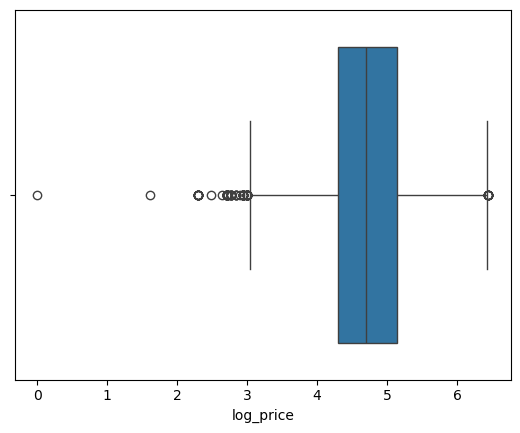

In [39]:
sns.boxplot(x = df['log_price'])
plt.show()

In [40]:
Q1 = df['city'].quantile(0.25)
Q3 = df['city'].quantile(0.75)
Q1 , Q3

(0.0, 2.0)

In [41]:
IQR = Q3-Q1
IQR

2.0

In [42]:
Min_Range = Q1 - (1.5*IQR)
Max_Range = Q3+(1.5*IQR)

In [43]:
Min_Range , Max_Range

(-3.0, 5.0)

In [44]:
df = df[df['city']<=Max_Range]

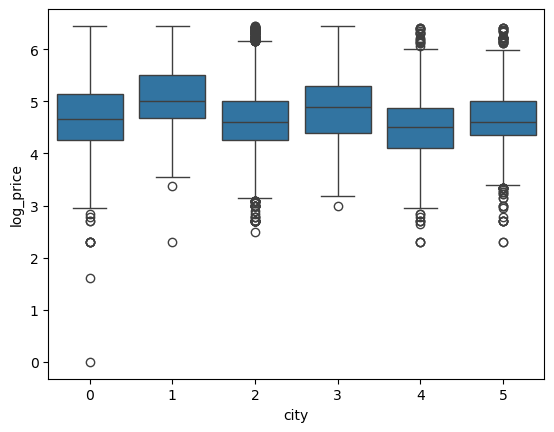

In [45]:
sns.boxplot(x='city',y='log_price',data=df)
plt.show()

# Exploaratory Data Analysis

In [47]:
#sns.pairplot(df)
#plt.show()

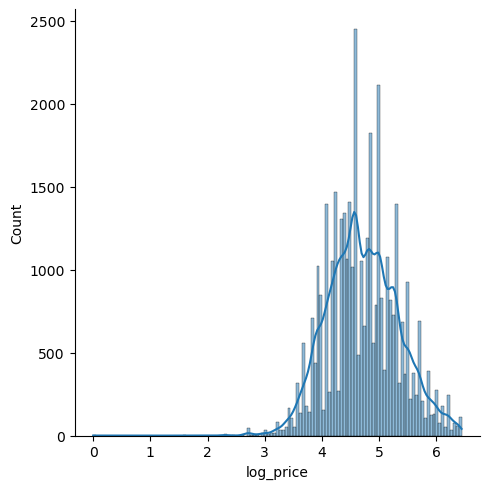

In [48]:
sns.displot(df['log_price'] , kde=True)
plt.show()

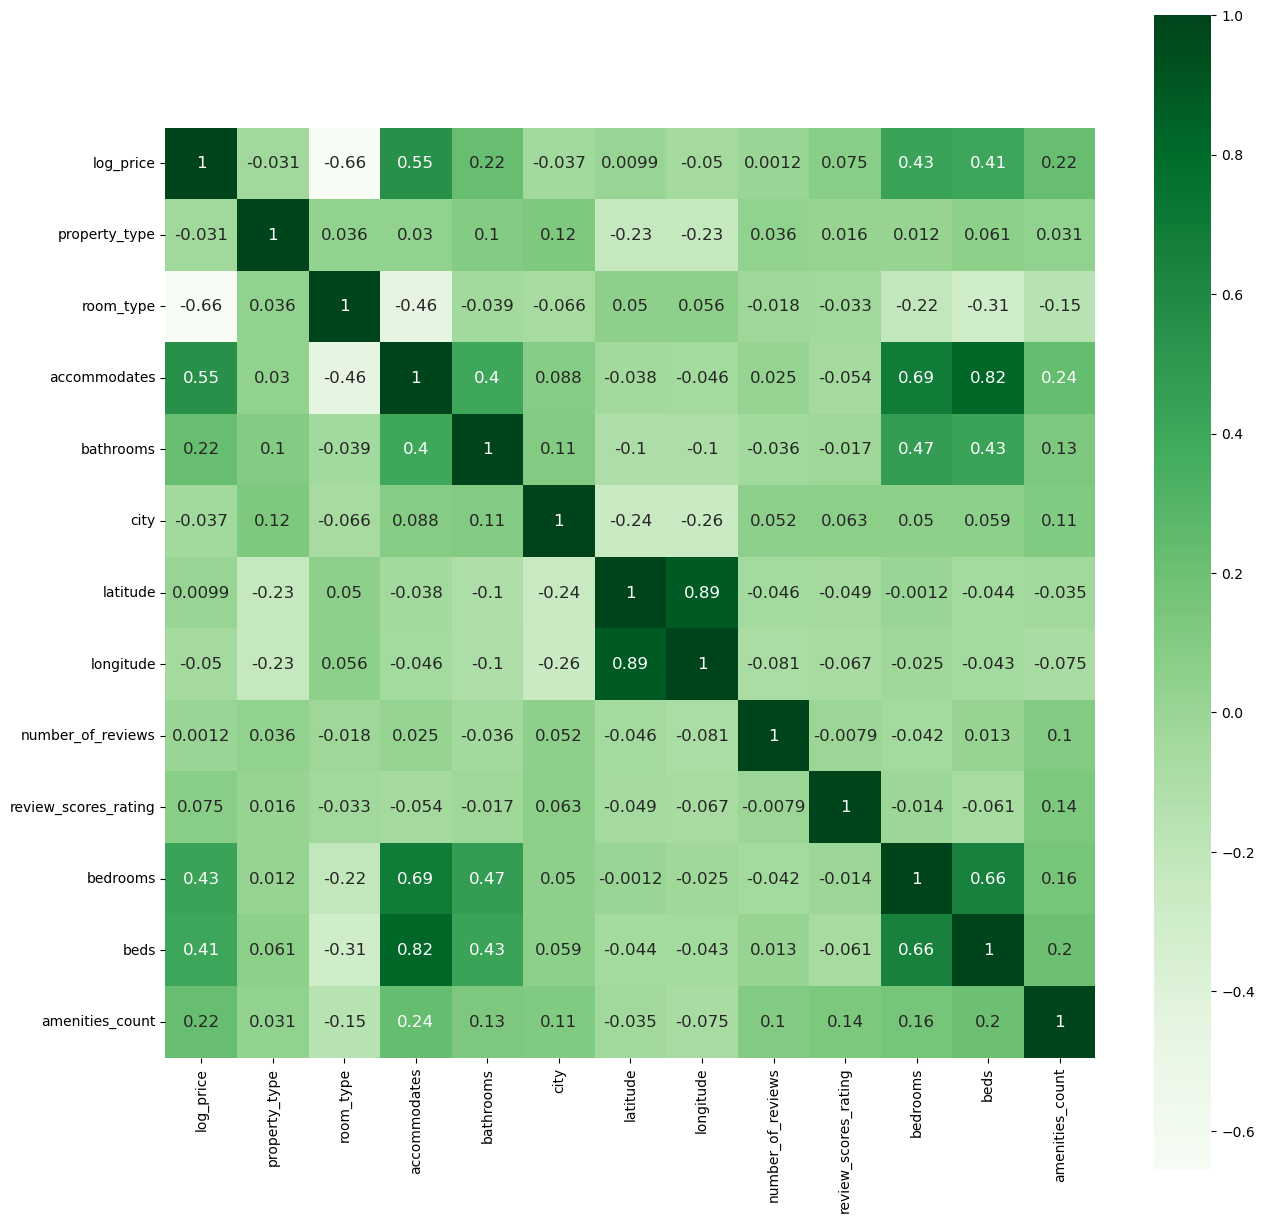

In [49]:
corr=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr , cbar=True,square=True,annot=True,annot_kws={'size':12} , cmap='Greens')
plt.show()

In [50]:
df['city'].value_counts()

city
0    17675
2     9923
1     3509
5     2391
3     2337
4     2192
Name: count, dtype: int64

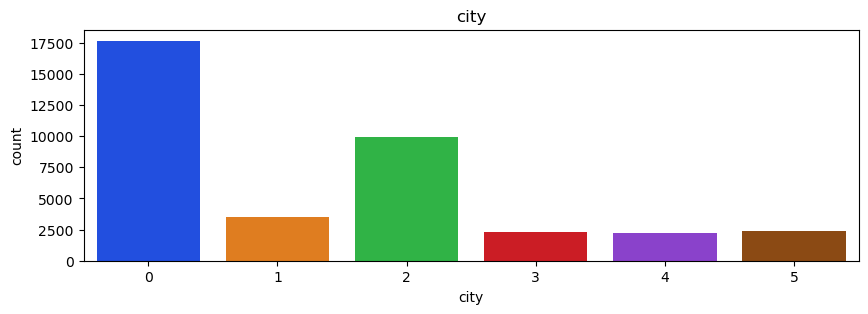

In [51]:
plt.figure(figsize = (10,3))
sns.countplot(x = 'city' , data = df , palette='bright')
plt.title('city')
plt.show()

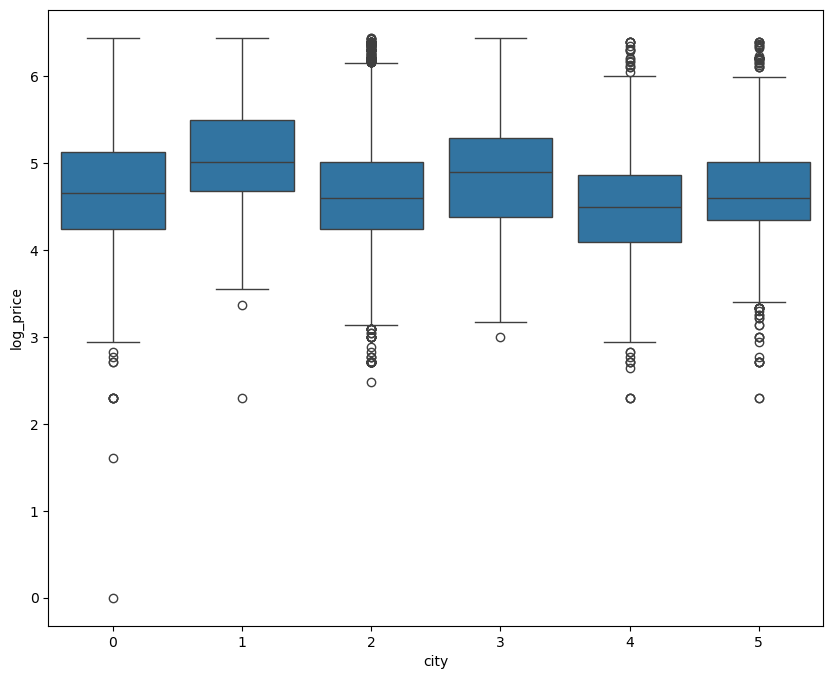

In [52]:
plt.figure(figsize=(10,8))
sns.boxplot(x='city',y='log_price',data=df)
plt.show()

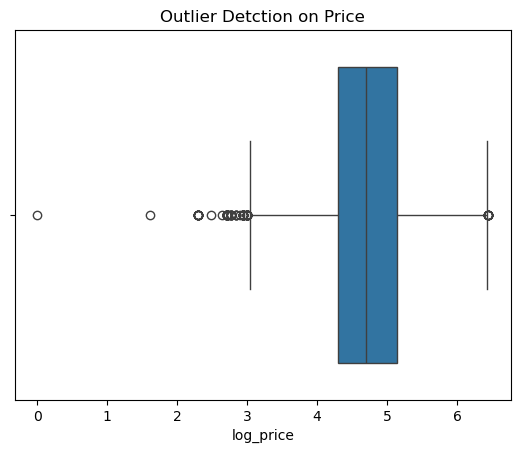

In [53]:
sns.boxplot(x = df['log_price'])
plt.title('Outlier Detction on Price')
plt.show()

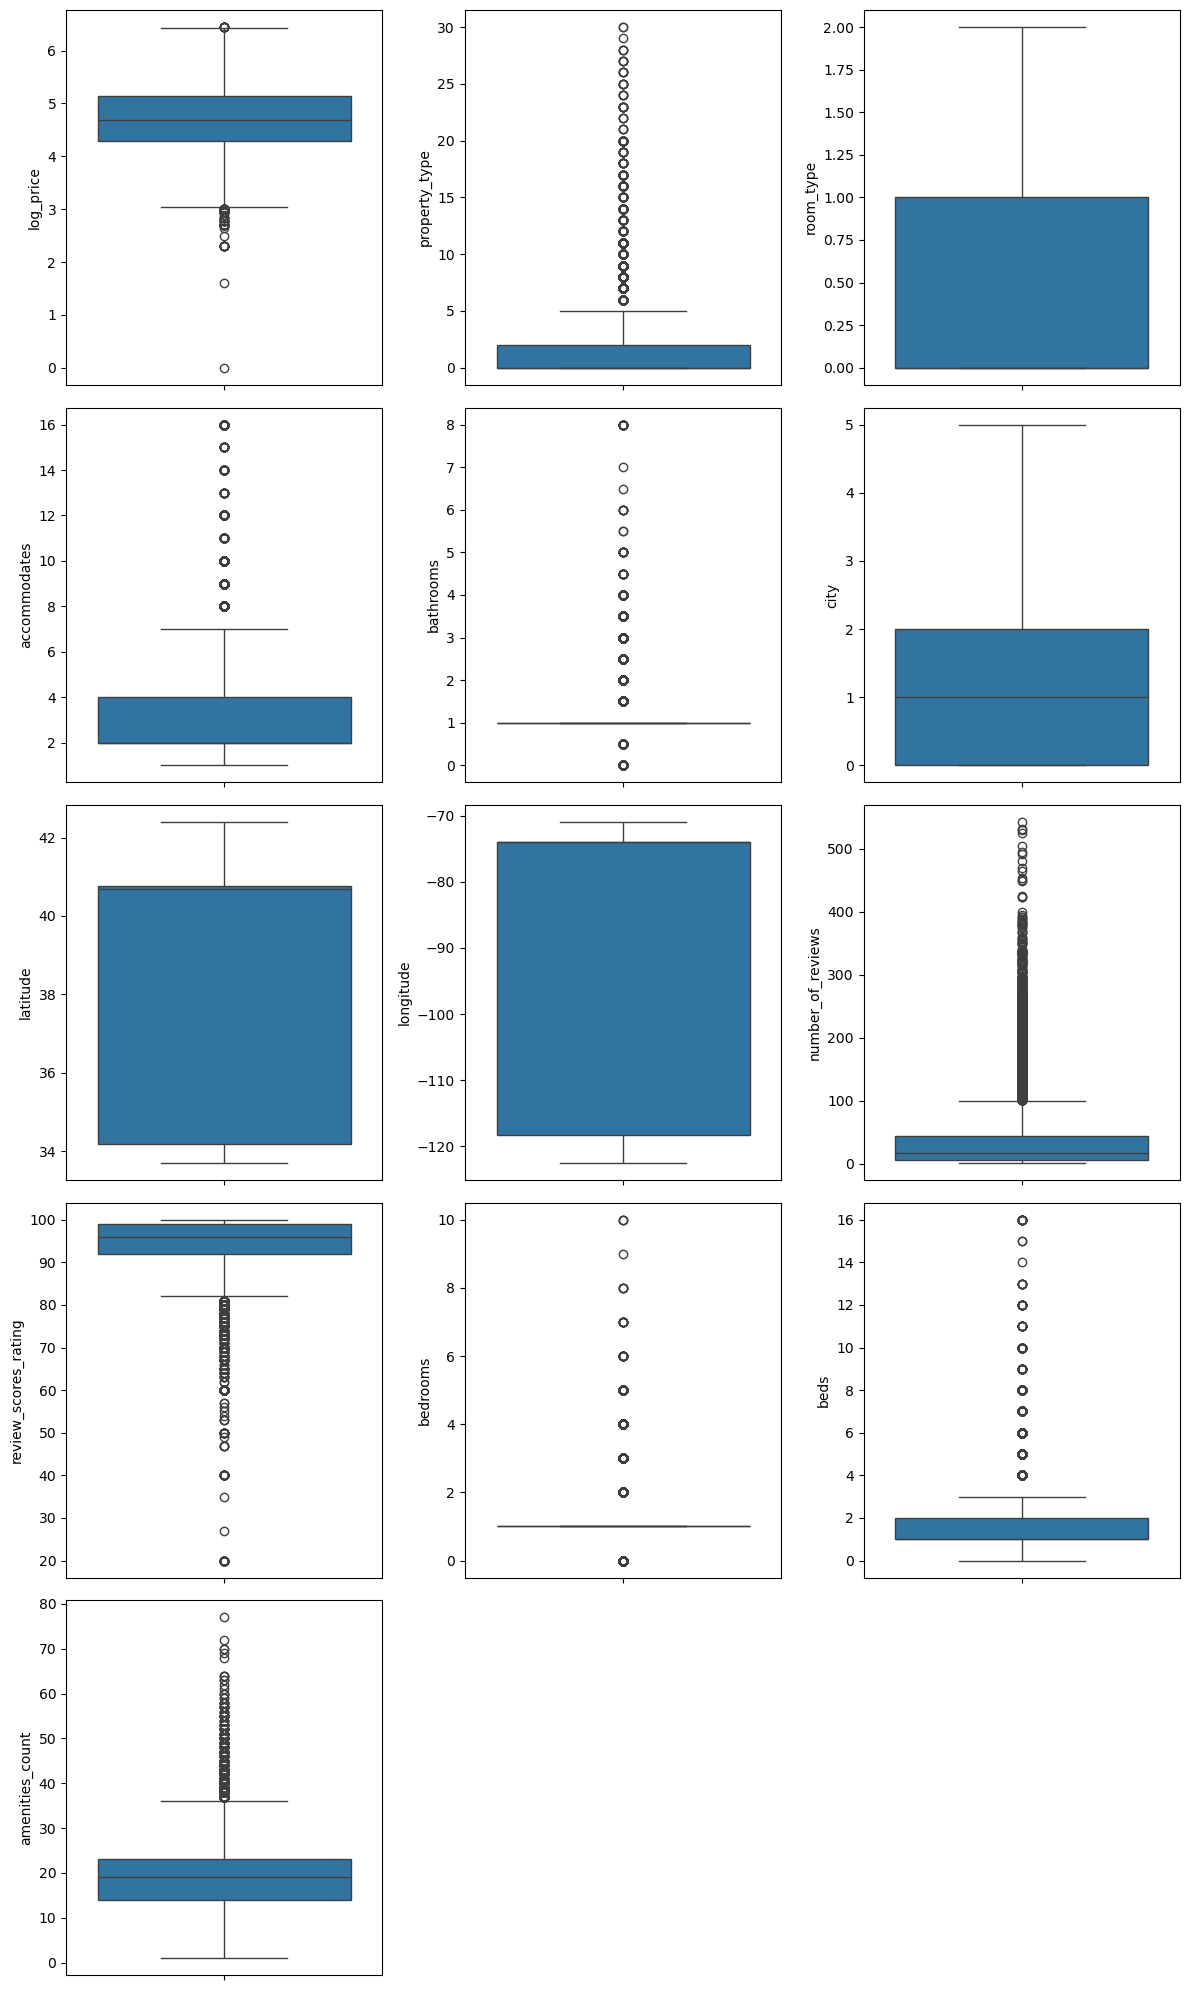

In [54]:
plt.figure(figsize=(12,20))
plotnum = 1
for columns in df :
    if plotnum <= len(df.columns) :
        ax=plt.subplot(5,3,plotnum)
        sns.boxplot(y=df[columns])
    plotnum +=1
plt.tight_layout()
plt.show()

# Feature Selection

In [56]:
X = df.drop(columns = 'log_price')
Y =  df['log_price']
print("[green]Seprating Sucessfully...[green]")

Seprating Sucessfully...

In [57]:
print(X.std())

property_type            2.400498
room_type                0.547522
accommodates             2.017648
bathrooms                0.500881
city                     1.542225
latitude                 3.006856
longitude               21.416040
number_of_reviews       45.601635
review_scores_rating     6.846313
bedrooms                 0.785351
beds                     1.221286
amenities_count          7.021335
dtype: float64

In [58]:
Y.std()

0.6205100304299582

# Split Data (Train & Test)

In [60]:
from sklearn.model_selection import train_test_split

In [61]:
X_train , X_test , Y_train , Y_test = train_test_split(X , Y , test_size=0.2 , random_state=42)

In [62]:
print("x shape:" , X.shape)
print("y shape:" , Y.shape)

print("x_train shape:" , X_train.shape)
print("x_test shape:" , X_test.shape)

print("y_train shape:" , Y_train.shape)
print("y_test shape:" , Y_test.shape)

x shape:
(38027, 12)

y shape:
(38027,)

x_train shape:
(30421, 12)

x_test shape:
(7606, 12)

y_train shape:
(30421,)

y_test shape:
(7606,)

# Model Selection

In [64]:
from sklearn.ensemble import RandomForestRegressor

In [65]:
RFR = RandomForestRegressor(
  n_estimators = 600 ,
  max_depth=14,
  min_samples_split=12,
  min_samples_leaf=4,
  max_features=0.8,
  bootstrap=True , 
  oob_score=True , 
  random_state=42 , 
  n_jobs=-1
)

In [66]:
RFR.fit(X_train , Y_train)

RandomForestRegressor(max_depth=14, max_features=0.8, min_samples_leaf=4,
                      min_samples_split=12, n_estimators=600, n_jobs=-1,
                      oob_score=True, random_state=42)

In [67]:
RFR.score(X_train , Y_train)

0.8332547364690408

In [68]:
RFR.score(X_test , Y_test)

0.7391523150470789

In [69]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

from sklearn.tree import DecisionTreeRegressor

DTR = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=10 , 
    min_samples_leaf=5 , 
    random_state=42,
)

DTR.fit(X_train, Y_train)

def regression_report(model, X_train, y_train, X_test, y_test, model_name):

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    train_r2 = r2_score(Y_train, y_train_pred)
    test_r2 = r2_score(Y_test, y_test_pred)

    train_mae = mean_absolute_error(Y_train, y_train_pred)
    test_mae = mean_absolute_error(Y_test, y_test_pred)

    train_rmse = np.sqrt(mean_squared_error(Y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred))

    # Print report
    print(f"\nRegression Report : {model_name}")
    print("="*40)

    print("R2 Score")
    print("Train:", round(train_r2,3))
    print("Test :", round(test_r2,3))

    print("\nMAE")
    print("Train:", round(train_mae,2))
    print("Test :", round(test_mae,2))

    print("\nRMSE")
    print("Train:", round(train_rmse,2))
    print("Test :", round(test_rmse,2))

    print("[bold green]Traing complete...[/bold green]")

In [70]:
from sklearn.ensemble import RandomForestRegressor

RFR = RandomForestRegressor(
    n_estimators=500,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

RFR.fit(X_train, Y_train)

regression_report(RFR, X_train, Y_train, X_test, Y_test, "Random Forest")

Regression Report : Random Forest

========================================

R2 Score

Train: 0.831

Test : 0.73

...

Test : 0.24

RMSE

Train: 0.26

Test : 0.32

Traing complete...

In [71]:
from sklearn.tree import DecisionTreeRegressor

DTR = DecisionTreeRegressor(
    max_depth=12,
    min_samples_split=10 , 
    min_samples_leaf=5 , 
    random_state=42,
)

DTR.fit(X_train, Y_train)

regression_report(RFR, X_train, Y_train, X_test, Y_test, "Decison Tree")

Regression Report : Decison Tree

========================================

R2 Score

Train: 0.831

Test : 0.73

...

Test : 0.24

RMSE

Train: 0.26

Test : 0.32

Traing complete...

In [72]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create model
DT = DecisionTreeRegressor(
    max_depth=12,          # control overfitting
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train model
DT.fit(X_train, Y_train)

# Predictions
y_train_pred = DT.predict(X_train)
y_test_pred = DT.predict(X_test)

# Calculate metrics
r2_train = r2_score(Y_train, y_train_pred)
r2_test = r2_score(Y_test, y_test_pred)

mae_train = mean_absolute_error(Y_train, y_train_pred)
mae_test = mean_absolute_error(Y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(Y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(Y_test, y_test_pred))

# Print report
print("[bold yellow] Regression report :Decision Tree Regressor [/bold yellow]")
print("="*40)

print("\nR2 Score")
print("Train:", round(r2_train, 2))
print("Test :", round(r2_test, 2))

print("\nMAE")
print("Train:", round(mae_train, 2))
print("Test :", round(mae_test, 2))

print("\nRMSE")
print("Train:", round(rmse_train, 2))
print("Test :", round(rmse_test, 2))

print("[bold green]Traing complete...[/bold green]")

 Regression report :Decision Tree Regressor 

========================================

R2 Score

Train: 0.79

Test : 0.66

...

Test : 0.27

RMSE

Train: 0.28

Test : 0.36

Traing complete...

In [73]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Create model
LR = LinearRegression()

# Train model
LR.fit(X_train, Y_train)

# Predictions
y_train_pred = LR.predict(X_train)
y_test_pred = LR.predict(X_test)

# Calculate metrics
r2_train = r2_score(Y_train, y_train_pred)
r2_test = r2_score(Y_test, y_test_pred)

mae_train = mean_absolute_error(Y_train, y_train_pred)
mae_test = mean_absolute_error(Y_test, y_test_pred)

rmse_train = np.sqrt(mean_squared_error(Y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(Y_test, y_test_pred))

# Print report
print("[bold yellow] Regression report :Linear Regression [/bold yellow]")
print("="*40)

print("\nR2 Score")
print("Train:", round(r2_train, 2))
print("Test :", round(r2_test, 2))

print("\nMAE")
print("Train:", round(mae_train, 2))
print("Test :", round(mae_test, 2))

print("\nRMSE")
print("Train:", round(rmse_train, 2))
print("Test :", round(rmse_test, 2))

print("[bold green]Traing complete...[/bold green]")

 Regression report :Linear Regression 

========================================

R2 Score

Train: 0.56

Test : 0.56

...

Test : 0.32

RMSE

Train: 0.41

Test : 0.41

Traing complete...

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Create models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=14, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=600,
        max_depth=14,
        min_samples_split=12,
        min_samples_leaf=4,
        max_features=0.8,
        random_state=42,
        n_jobs=-1
    )
}

# Store results
results = []

# Train and evaluate each model
for name, model in models.items():

    # Train
    model.fit(X_train, Y_train)

    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    r2_train = r2_score(Y_train, y_train_pred)
    r2_test = r2_score(Y_test, y_test_pred)

    mae_test = mean_absolute_error(Y_test, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(Y_test, y_test_pred))

    # Save resultss
    results.append({
        "Model": name,
        "Train R2": round(r2_train, 3),
        "Test R2": round(r2_test, 3),
        "MAE": round(mae_test, 2),
        "RMSE": round(rmse_test, 2)
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Show all models performance
print("[bold yellow] Shows all models Performance : [/bold yellow]")
print("="*50)
print(results_df)

# Select best model based on Test R2
best_model = results_df.loc[results_df["Test R2"].idxmax()]

print("\nBest Model Selected")
print("="*50)
print(best_model)

 Shows all models Performance : 

==================================================

Model  Train R2  Test R2   MAE  RMSE
0  Linear Regression     0.562    0.564  0.32  0.41
1      Decision Tree     0.858    0.612  0.29  0.39
2      Random Forest     0.833    0.739  0.24  0.32

Best Model Selected

==================================================

Model       Random Forest
Train R2            0.833
Test R2             0.739
MAE                  0.24
RMSE                 0.32
Name: 2, dtype: object

# Model Evaluation

In [76]:
import pandas as pd

results = {
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "Train R2": [0.68, 0.95, 0.82],
    "Test R2": [0.65, 0.72, 0.78],
    "Test RMSE": [45.2, 38.5, 35.8]
}

results_df = pd.DataFrame(results)


 Test RMSE (Lower is better): 

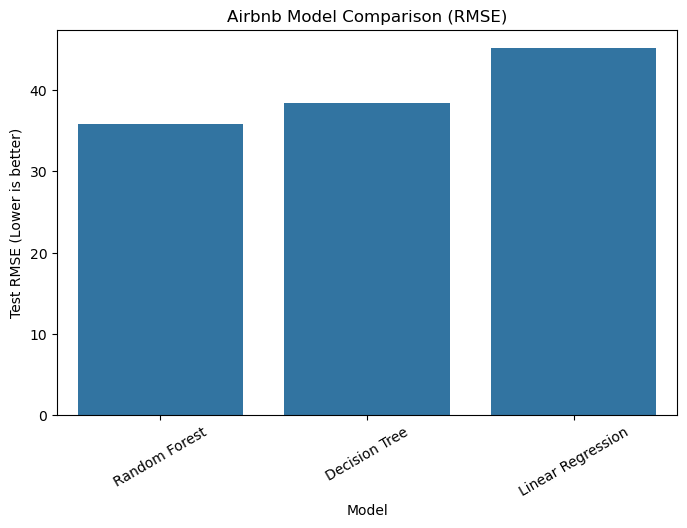

In [77]:
print("[bold yellow] Test RMSE (Lower is better): [/bold yellow]")

plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Test RMSE",
    data=results_df.sort_values(by="Test RMSE", ascending=True)
)

plt.title("Airbnb Model Comparison (RMSE)")
plt.ylabel("Test RMSE (Lower is better)")
plt.xlabel("Model")
plt.xticks(rotation=30)

plt.show()


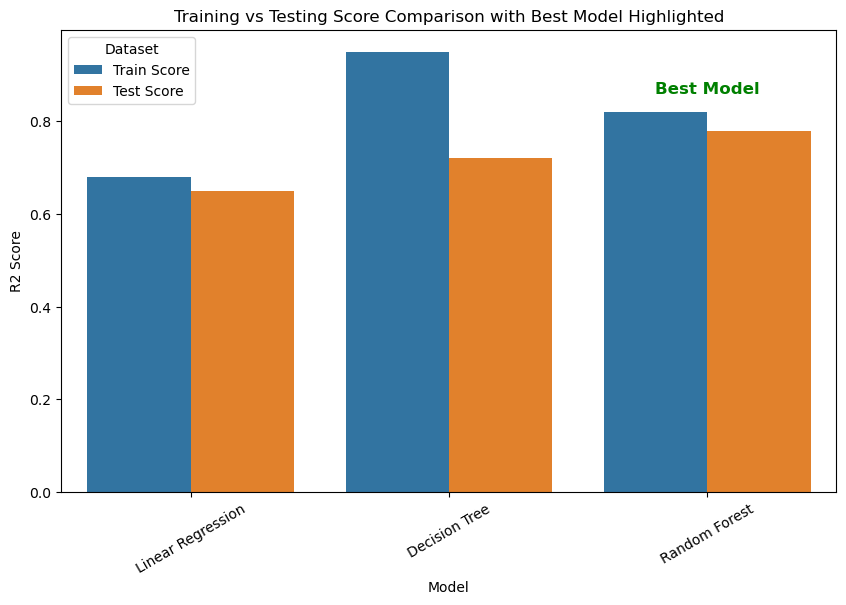

Best Fitting Model: Random Forest

Test Score: 0.78

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example results (replace with your real scores)
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "Train Score": [0.68, 0.95, 0.82],
    "Test Score": [0.65, 0.72, 0.78]
})

# Find best model based on Test Score
best_model = results_df.loc[results_df["Test Score"].idxmax(), "Model"]
best_score = results_df["Test Score"].max()

# Convert to long format
results_melted = results_df.melt(id_vars="Model",
                                 var_name="Dataset",
                                 value_name="Score")

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x="Model",
    y="Score",
    hue="Dataset",
    data=results_melted
)

# Highlight best model
for i, model in enumerate(results_df["Model"]):
    if model == best_model:
        ax.text(i, best_score + 0.08,
                "Best Model",
                ha='center',
                color='green',
                fontsize=12,
                fontweight='bold')

plt.title("Training vs Testing Score Comparison with Best Model Highlighted")
plt.ylabel("R2 Score")
plt.xlabel("Model")
plt.xticks(rotation=30)

plt.show()

# Print best model also
print("Best Fitting Model:", best_model)
print("Test Score:", best_score)


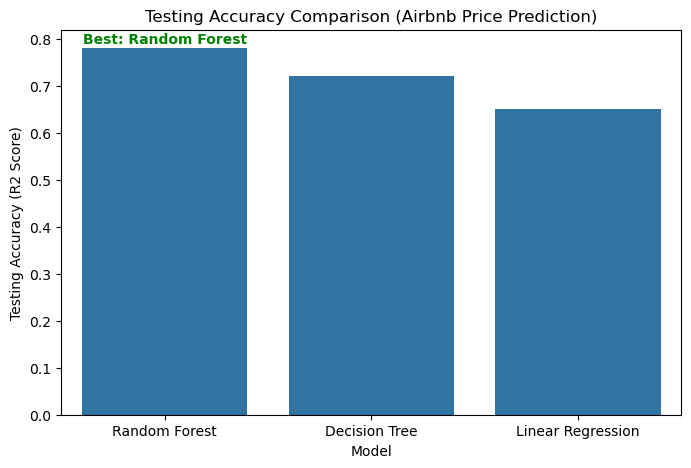

Best Model: Random Forest

Testing Accuracy: 0.78

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Example results (replace with your actual scores)
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "Test Accuracy": [0.65, 0.72, 0.78]   # Test R2 score
})

# Sort models by testing accuracy
results_df = results_df.sort_values(by="Test Accuracy", ascending=False)

# Plot graph
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Test Accuracy",
    data=results_df
)

# Highlight best model
best_model = results_df.iloc[0]["Model"]
best_score = results_df.iloc[0]["Test Accuracy"]

plt.text(0, best_score + 0.01,
         f"Best: {best_model}",
         ha='center',
         color='green',
         fontweight='bold')

plt.title("Testing Accuracy Comparison (Airbnb Price Prediction)")
plt.ylabel("Testing Accuracy (R2 Score)")
plt.xlabel("Model")


plt.show()

print("Best Model:", best_model)
print("Testing Accuracy:", best_score)


# Model Saving

In [81]:
import joblib
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Example: use your actual X and y
# y should be log-transformed (np.log1p(price))

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, Y_train)

# Save model
joblib.dump(model, "airbnb_price_model.pkl")

print("Model saved successfully")


Model saved successfully

In [180]:
X.head(2)

,property_type,room_type,accommodates,bathrooms,city,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,amenities_count
1,0.0,0,7,1.0,0,40.766115,-73.989040,6,93.0,3.0,3.0,15
2,0.0,0,5,1.0,0,40.808110,-73.943756,10,92.0,1.0,3.0,19


# Prediction System

In [184]:
import numpy as np
import joblib

# Load model
model = joblib.load("airbnb_price_model.pkl")

# Prediction function
def predict_price(property_type, room_type, accommodates, bathrooms, city, latitude, longitude, number_of_reviews, review_scores_rating, bedrooms, beds , amenities_count):

    input_data = np.array([[property_type, room_type, accommodates, bathrooms, city, latitude, longitude, number_of_reviews, review_scores_rating, bedrooms, beds , amenities_count]])

    log_price = model.predict(input_data)

    price = np.expm1(log_price)

    return round(price[0], 2)


# Test prediction
print("Predicted Price: $", predict_price(2.0 ,1 ,2, 1.5 ,0	,40.656278	,-73.922645	,57	,89.0	,1.0	,1.0	,15))


Predicted Price: $ 43.85

In [84]:
X.head(10)

,property_type,room_type,accommodates,bathrooms,city,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,amenities_count
1,0.0,0,7,1.0,0,40.766115,-73.989040,6,93.0,3.0,3.0,15
2,0.0,0,5,1.0,0,40.808110,-73.943756,10,92.0,1.0,3.0,19
5,0.0,1,2,1.0,1,37.753164,-122.429526,3,100.0,1.0,1.0,10
7,1.0,0,2,1.0,2,34.046737,-118.260439,9,93.0,1.0,1.0,26
8,2.0,1,2,1.0,1,37.781128,-122.501095,159,99.0,1.0,1.0,21
10,0.0,1,2,1.0,0,40.723883,-73.983880,82,93.0,1.0,1.0,15
17,4.0,1,2,2.0,3,42.339194,-71.049672,12,88.0,1.0,1.0,19
19,2.0,0,8,1.0,0,40.643773,-73.950855,5,72.0,3.0,3.0,24
20,2.0,1,2,1.0,2,34.165795,-118.444462,26,98.0,1.0,1.0,21
21,2.0,1,2,1.5,0,40.656278,-73.922645,57,89.0,1.0,1.0,11


In [85]:
Y_data = np.expm1(df['log_price'])

In [86]:
Y_data.head(10)

1     168.0
2     144.0
5      84.0
7     119.0
8     119.0
10     99.0
17     98.0
19     98.0
20     79.0
21     39.0
Name: log_price, dtype: float64